In [1]:
import matplotlib.pyplot as plt
import numpy as np

import pybamm

model = pybamm.lithium_ion.SPMe()
sim = pybamm.Simulation(model)
sim.solve([0, 3600])

In [2]:
solution = sim.solution

In [3]:
solution = sim.solve([0, 3600])

In [4]:
t = solution["Time [s]"]
v = solution["Voltage [V]"]

In [5]:
v.entries

array([3.77081317, 3.77079279, 3.77077254, 3.77073231, 3.77065324,
       3.77049952, 3.77021771, 3.76995259, 3.76947399, 3.76903603,
       3.76863064, 3.76787865, 3.7672045 , 3.76600987, 3.76506801,
       3.76420935, 3.76341241, 3.76266442, 3.7612911 , 3.76004184,
       3.7588895 , 3.7578216 , 3.75682942, 3.75503565, 3.75344643,
       3.75201702, 3.75071602, 3.74952015, 3.74841036, 3.74737186,
       3.74546111, 3.74388578, 3.74210993, 3.74059926, 3.73914878,
       3.73774197, 3.73636906, 3.73502304, 3.73369936, 3.73110466,
       3.72857096, 3.7260876 , 3.72125552, 3.7171124 , 3.71309641,
       3.70921096, 3.70545836, 3.70183936, 3.69500063, 3.688684  ,
       3.68286921, 3.67752799, 3.67262547, 3.66396455, 3.65641393,
       3.63864846, 3.59791633, 3.48889622, 3.17239789])

In [6]:
v([200, 400, 600, 800, 1000])

array([3.7298096 , 3.70895128, 3.69143819, 3.6771513 , 3.6656144 ])

In [7]:
model.variables

{'Time [s]': Time(0x33846ee1b1909623, time, children=[], domains={}),
 'Time [min]': Multiplication(-0x278943c1b4f16573, *, children=['0.016666666666666666', 'time'], domains={}),
 'Time [h]': Multiplication(-0x4549e4d0858a53d8, *, children=['0.0002777777777777778', 'time'], domains={}),
 'x [m]': SpatialVariable(0x63653bab111ced15, x, children=[], domains={'primary': ['negative electrode', 'separator', 'positive electrode'], 'secondary': ['current collector']}),
 'x_n [m]': SpatialVariable(0x44de742098668c94, x_n, children=[], domains={'primary': ['negative electrode'], 'secondary': ['current collector']}),
 'x_s [m]': SpatialVariable(-0x3f1ea71de67db0df, x_s, children=[], domains={'primary': ['separator'], 'secondary': ['current collector']}),
 'x_p [m]': SpatialVariable(-0x368d8e3ce5597960, x_p, children=[], domains={'primary': ['positive electrode'], 'secondary': ['current collector']}),
 'r_n [m]': SpatialVariable(0x6e67822a53138927, r_n, children=[], domains={'primary': ['negativ

In [9]:
conductance_symbol = model.variables["Current [A]"] / model.variables["Voltage [V]"]
conductance = solution.observe(conductance_symbol)
conductance

Text(0, 0.5, 'conductance [S]')

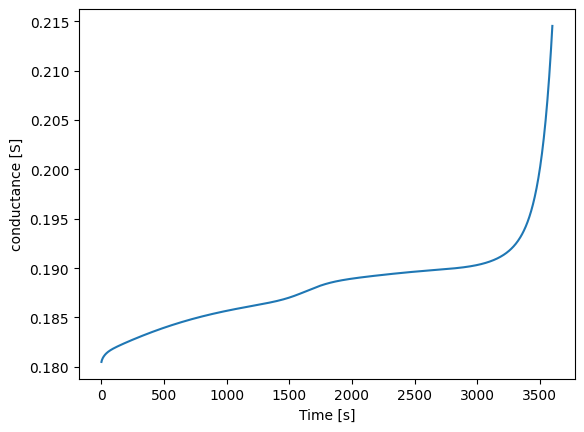

In [10]:
t = np.linspace(0, solution.t[-1], 1000)

plt.plot(t, conductance(t))
plt.xlabel("Time [s]")
plt.ylabel("conductance [S]")

In [11]:
sim.save("SPMe.pkl")

In [12]:
sim2 = pybamm.load("SPMe.pkl")

In [13]:
sim2.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.01), Output()), _dom_classes=('w…

In [14]:
sol = sim.solution
sol.save("SPMe_sol.pkl")

In [15]:
sol2 = pybamm.load("SPMe_sol.pkl")
sol2.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.01), Output()), _dom_classes=('w…